In [3]:
import sys
print(sys.executable)


c:\Users\91994\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
import sys
sys.executable


'c:\\Users\\91994\\AppData\\Local\\Programs\\Python\\Python310\\python.exe'

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)



NumPy: 1.24.3
Pandas: 1.5.3
TensorFlow: 2.15.0


In [1]:
%pip install numpy==1.24.3 pandas==1.5.3 tensorflow==2.15.0 scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
# Imports & environment
import os, random, math, gc, sys, json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
SEED = 42
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

TensorFlow: 2.15.0
GPU Available: []


In [6]:
from pathlib import Path
import pandas as pd

# Local path (VS Code)
DATA_DIR = Path("data")  # adjust if your folder name is different
IMG_DIR  = DATA_DIR / "email_images" / "email_images"
CSV_PATH = DATA_DIR / "email_images" / "manifest.csv"

# Check if paths exist
assert CSV_PATH.exists(), f"Missing CSV at {CSV_PATH}"
assert IMG_DIR.exists(), f"Missing images at {IMG_DIR}"

# Load CSV
df = pd.read_csv(CSV_PATH)
print(df.head())
print("\nRows:", len(df))

# Create image paths
df['image_path'] = df['row_index'].apply(
    lambda i: IMG_DIR / f"email_{i:05d}.png"
)

# Check for missing images
missing = df[~df['image_path'].apply(Path.exists)]
print("Missing images:", len(missing))
missing.head()


                                          image_path  label  row_index  \
0  C:\Users\cs001\Downloads\Compressed\Phishing_E...      0          0   
1  C:\Users\cs001\Downloads\Compressed\Phishing_E...      0          1   
2  C:\Users\cs001\Downloads\Compressed\Phishing_E...      0          2   
3  C:\Users\cs001\Downloads\Compressed\Phishing_E...      1          3   
4  C:\Users\cs001\Downloads\Compressed\Phishing_E...      1          4   

  template  dark_mode                                subject  
0  Outlook      False  Important: Disc Uniformitarianism Sex  
1    Gmail      False              Important: The Other Side  
2    Gmail       True       Important: Equistar Deal Tickets  
3    Gmail      False     Hello I am your hot lil horny toy.  
4   Mobile      False     Important: Software Incredibly Low  

Rows: 1000
Missing images: 0


,image_path,label,row_index,template,dark_mode,subject


In [ ]:
print(df['label'].value_counts())
df['subject_len'] = df['subject'].astype(str).str.len()
print(df['subject_len'].describe())

display(df.query("label==1").head(3)[['row_index','template','dark_mode','subject']])
display(df.query("label==0").head(3)[['row_index','template','dark_mode','subject']])

0    596
1    404
Name: label, dtype: int64
count    1000.000000
mean       35.829000
std        11.329171
min         1.000000
25%        28.000000
50%        33.000000
75%        44.000000
max        53.000000
Name: subject_len, dtype: float64


,row_index,template,dark_mode,subject
3,3,Gmail,False,Hello I am your hot lil horny toy.
4,4,Mobile,False,Important: Software Incredibly Low
7,7,Outlook,False,Important: Entourage Stockmogul Newsletter


,row_index,template,dark_mode,subject
0,0,Outlook,False,Important: Disc Uniformitarianism Sex
1,1,Gmail,False,Important: The Other Side
2,2,Gmail,True,Important: Equistar Deal Tickets


In [8]:
# Train/Val/Test split
train_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=SEED)
train_df, val_df  = train_test_split(train_df, test_size=0.15, stratify=train_df['label'], random_state=SEED)

for name, d in [('train',train_df),('val',val_df),('test',test_df)]:
    print(name, len(d), "phish:", d['label'].sum(), "legit:", len(d)-d['label'].sum())

train 722 phish: 291 legit: 431
val 128 phish: 52 legit: 76
test 150 phish: 61 legit: 89


In [9]:
# Configs
IMG_SIZE   = (224, 224)   # EfficientNet-friendly
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

# Text vectorization params
MAX_TOKENS = 2000     # vocabulary size (subjects are short; 2k is enough)
MAX_LEN    = 24       # max tokens per subject (most subjects are short)

In [10]:
# Example parser for a single row -> (image_tensor, subject_string, label)
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def make_dataset(frame, training=False):
    paths   = frame['image_path'].astype(str).tolist()
    texts   = frame['subject'].astype(str).tolist()
    labels  = frame['label'].astype(np.float32).tolist()

    ds_img  = tf.data.Dataset.from_tensor_slices(paths).map(lambda p: load_image(p), num_parallel_calls=AUTOTUNE)
    ds_txt  = tf.data.Dataset.from_tensor_slices(texts)
    ds_lab  = tf.data.Dataset.from_tensor_slices(labels)

    ds = tf.data.Dataset.zip(((ds_img, ds_txt), ds_lab))

    # Augment only images when training
    if training:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.02),
            layers.RandomZoom(0.1),
        ])
        ds = ds.map(lambda x, y: ((aug(x[0], training=True), x[1]), y), num_parallel_calls=AUTOTUNE)

    ds = ds.shuffle(2048, seed=SEED) if training else ds
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

In [11]:
# Text vectorization layer
vectorizer = layers.TextVectorization(
    standardize='lower_and_strip_punctuation',
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=MAX_LEN,
)

# Adapt on training text only
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(train_df['subject'].astype(str).values).batch(256))

# Save vocabulary size for embedding
vocab_size = len(vectorizer.get_vocabulary())
print("Vocab size:", vocab_size)


Vocab size: 1630


In [12]:
# Image branch (EfficientNetB0) + Text branch (BiLSTM) + Fusion
# IMAGE BRANCH
img_in = keras.Input(shape=(*IMG_SIZE, 3), name="image")
base = keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_tensor=img_in, pooling=None)
base.trainable = False  # start with frozen backbone, we'll unfreeze later
x_img = base.output
x_img = layers.GlobalAveragePooling2D()(x_img)
x_img = layers.Dropout(0.25)(x_img)

# TEXT BRANCH
txt_in = keras.Input(shape=(), dtype=tf.string, name="subject_text")
x_txt = vectorizer(txt_in)
x_txt = layers.Embedding(vocab_size, 128, mask_zero=True)(x_txt)
x_txt = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x_txt)
x_txt = layers.Dropout(0.25)(x_txt)

# FUSION
x = layers.Concatenate()([x_img, x_txt])
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
out = layers.Dense(1, activation="sigmoid", name="phish_prob")(x)

model = keras.Model(inputs=[img_in, txt_in], outputs=out)
model.summary()


16705208/16705208 [==============================] - 20s 1us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image (InputLayer)          [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['image[0][0]']               
                                                                                                  
 normalization (Normalizati  (None, 224, 224, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)   

In [13]:
# Cell 9 — Rebuild model (no LSTM mask) + compile + train (stage 1)

# Why rebuild?
# The previous text branch used Embedding(mask_zero=True) which creates a mask tensor.
# With cuDNN-accelerated LSTM this must be STRICTLY right-padded; some TF builds
# still trip an assertion here. We remove masking (mask_zero=False) and keep
# fixed-length sequences from TextVectorization, which avoids the crash.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import gc

keras.backend.clear_session()
gc.collect()

# --- IMAGE BRANCH (reuse EfficientNet backbone created in Cell 8) ---
# Assumes `base` (EfficientNetB0) already exists from Cell 8.
# If you changed its variable name, update this reference.
base.trainable = False  # keep frozen for stage 1

img_in = keras.Input(shape=(*IMG_SIZE, 3), name="image")
x_img  = base(img_in, training=False)
x_img  = layers.GlobalAveragePooling2D()(x_img)
x_img  = layers.Dropout(0.25)(x_img)

# --- TEXT BRANCH (no masking) ---
# Assumes `vectorizer` and `vocab_size` were created earlier.
txt_in = keras.Input(shape=(), dtype=tf.string, name="subject_text")
x_txt  = vectorizer(txt_in)                                 # shape: (batch, MAX_LEN) ints
x_txt  = layers.Embedding(vocab_size, 128, mask_zero=False)(x_txt)  # <— no mask
x_txt  = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x_txt)
x_txt  = layers.Dropout(0.25)(x_txt)

# --- FUSION HEAD ---
x   = layers.Concatenate()([x_img, x_txt])
x   = layers.Dense(256, activation="relu")(x)
x   = layers.Dropout(0.30)(x)
x   = layers.Dense(64, activation="relu")(x)
out = layers.Dense(1, activation="sigmoid", name="phish_prob")(x)

model = keras.Model(inputs=[img_in, txt_in], outputs=out)
model.summary()

# --- COMPILE ---
lr = 1e-3
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="acc")]
)

# --- CALLBACKS ---
ckpt = keras.callbacks.ModelCheckpoint(
    "hybrid_frozen.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)
es = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=4,
    restore_best_weights=True
)

# --- TRAIN (stage 1: CNN frozen) ---
hist1 = model.fit(
    train_ds,
    epochs=8,
    validation_data=val_ds,
    callbacks=[ckpt, es],
    verbose=1
)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 subject_text (InputLayer)   [(None,)]                    0         []                            
                                                                                                  
 image (InputLayer)          [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 text_vectorization (TextVe  (None, 24)                   0         ['subject_text[0][0]']        
 ctorization)                                                                                     
                                                                                                  
 efficientnetb0 (Functional  (None, 7, 7, 1280)           4049571   ['image[0][0]']           

In [14]:
# Fine-tuning stage (small LR, unfreeze top blocks)

from tensorflow import keras
from tensorflow.keras import layers

# Unfreeze the top portion of the EfficientNet backbone
# (assumes `base` is the EfficientNetB0 instance created earlier)
freeze_until = int(len(base.layers) * 0.6)   # keep bottom 60% frozen
for i, layer in enumerate(base.layers):
    trainable = (i >= freeze_until) and not isinstance(layer, layers.BatchNormalization)
    layer.trainable = trainable

# Recompile with a smaller LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="acc")]
)

ckpt2 = keras.callbacks.ModelCheckpoint(
    "hybrid_finetuned.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)
es2 = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)
rlr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

hist2 = model.fit(
    train_ds,
    epochs=12,
    validation_data=val_ds,
    callbacks=[ckpt2, es2, rlr],
    verbose=1
)

Epoch 1/12
23/23 [==============================] - ETA: 0s - loss: 0.0532 - auc: 0.9970 - acc: 0.9820
Epoch 1: val_auc improved from -inf to 0.88917, saving model to hybrid_finetuned.keras
23/23 [==============================] - 31s 843ms/step - loss: 0.0532 - auc: 0.9970 - acc: 0.9820 - val_loss: 0.4829 - val_auc: 0.8892 - val_acc: 0.7891 - lr: 1.0000e-04
Epoch 2/12
23/23 [==============================] - ETA: 0s - loss: 0.0543 - auc: 0.9970 - acc: 0.9834
Epoch 2: val_auc did not improve from 0.88917
23/23 [==============================] - 20s 757ms/step - loss: 0.0543 - auc: 0.9970 - acc: 0.9834 - val_loss: 0.5050 - val_auc: 0.8889 - val_acc: 0.7969 - lr: 1.0000e-04
Epoch 3/12
23/23 [==============================] - ETA: 0s - loss: 0.0435 - auc: 0.9975 - acc: 0.9806
Epoch 3: val_auc did not improve from 0.88917

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
23/23 [==============================] - 21s 750ms/step - loss: 0.0435 - auc: 0.9975 - acc: 0

In [15]:
# Evaluate on test set
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

pred_prob = model.predict(test_ds).ravel()
y_true    = np.concatenate([y for (_, y) in test_ds], axis=0)

auc = roc_auc_score(y_true, pred_prob)
print("Test ROC AUC:", round(auc, 4))

# Default 0.5 threshold
y_pred_05 = (pred_prob >= 0.5).astype(int)
print("\nClassification report @0.5:\n", classification_report(y_true, y_pred_05, digits=4))
print("Confusion matrix @0.5:\n", confusion_matrix(y_true, y_pred_05))

5/5 [==============================] - 12s 1s/step
Test ROC AUC: 0.8996

Classification report @0.5:
               precision    recall  f1-score   support

         0.0     0.8846    0.7753    0.8263        89
         1.0     0.7222    0.8525    0.7820        61

    accuracy                         0.8067       150
   macro avg     0.8034    0.8139    0.8042       150
weighted avg     0.8186    0.8067    0.8083       150

Confusion matrix @0.5:
 [[69 20]
 [ 9 52]]


In [16]:
# Pick threshold on the VALIDATION set (so test stays clean)

import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve, roc_auc_score

# Collect val labels and probabilities
val_probs = model.predict(val_ds).ravel()
val_true  = np.concatenate([y for (_, y) in val_ds], axis=0)

# Sweep thresholds and optimize F1 (or use Youden's J if you prefer balanced sensitivity/specificity)
ths = np.linspace(0.05, 0.95, 19)
best = {"thr": 0.5, "f1": -1, "prec": None, "rec": None}

for t in ths:
    yp = (val_probs >= t).astype(int)
    f1 = f1_score(val_true, yp)
    pr, rc, _ = precision_recall_curve(val_true, val_probs)
    if f1 > best["f1"]:
        best = {"thr": float(t), "f1": float(f1)}

print("Best F1 threshold on VAL:", best)

BEST_THR = best["thr"]

4/4 [==============================] - 4s 896ms/step
Best F1 threshold on VAL: {'thr': 0.39999999999999997, 'f1': 0.7758620689655172}


In [17]:
# Apply threshold chosen on VAL to the TEST set

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

test_probs = model.predict(test_ds).ravel()
test_true  = np.concatenate([y for (_, y) in test_ds], axis=0)

print("Test ROC AUC (unchanged by threshold):", roc_auc_score(test_true, test_probs))

y_pred_opt = (test_probs >= BEST_THR).astype(int)
print(f"\nClassification report @{BEST_THR:.2f}:\n",
      classification_report(test_true, y_pred_opt, digits=4))
print(f"Confusion matrix @{BEST_THR:.2f}:\n", confusion_matrix(test_true, y_pred_opt))

5/5 [==============================] - 4s 749ms/step
Test ROC AUC (unchanged by threshold): 0.8996131884324922

Classification report @0.40:
               precision    recall  f1-score   support

         0.0     0.8947    0.7640    0.8242        89
         1.0     0.7162    0.8689    0.7852        61

    accuracy                         0.8067       150
   macro avg     0.8055    0.8164    0.8047       150
weighted avg     0.8221    0.8067    0.8084       150

Confusion matrix @0.40:
 [[68 21]
 [ 8 53]]


In [18]:
# Encode template and dark_mode

from sklearn.preprocessing import LabelEncoder

# Encode template as integers (Outlook, Gmail, Mobile, etc.)
lbl_enc = LabelEncoder()
train_df["template_enc"] = lbl_enc.fit_transform(train_df["template"])
val_df["template_enc"]   = lbl_enc.transform(val_df["template"])
test_df["template_enc"]  = lbl_enc.transform(test_df["template"])

# Map dark_mode to int (True=1, False=0)
for df_ in [train_df, val_df, test_df]:
    df_["dark_mode_int"] = df_["dark_mode"].astype(int)

n_templates = len(lbl_enc.classes_)
print("Templates:", lbl_enc.classes_, " →", n_templates, "categories")

Templates: ['Gmail' 'Mobile' 'Outlook']  → 3 categories


In [19]:
# Build tf.data pipeline with metadata

def make_dataset_meta(frame, training=False):
    paths   = frame['image_path'].astype(str).tolist()
    texts   = frame['subject'].astype(str).tolist()
    labels  = frame['label'].astype(np.float32).tolist()
    tmps    = frame['template_enc'].astype(np.int32).tolist()
    darks   = frame['dark_mode_int'].astype(np.int32).tolist()

    ds_img   = tf.data.Dataset.from_tensor_slices(paths).map(lambda p: load_image(p), num_parallel_calls=AUTOTUNE)
    ds_txt   = tf.data.Dataset.from_tensor_slices(texts)
    ds_lab   = tf.data.Dataset.from_tensor_slices(labels)
    ds_tmp   = tf.data.Dataset.from_tensor_slices(tmps)
    ds_dark  = tf.data.Dataset.from_tensor_slices(darks)

    ds = tf.data.Dataset.zip((
        {"image": ds_img, "subject_text": ds_txt, "template": ds_tmp, "dark_mode": ds_dark},
        ds_lab
    ))

    if training:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.02),
            layers.RandomZoom(0.1),
        ])
        def _aug_map(x, y):
            x = dict(x)
            x["image"] = aug(x["image"], training=True)
            return x, y
        ds = ds.map(_aug_map, num_parallel_calls=AUTOTUNE)

    ds = ds.shuffle(2048, seed=SEED) if training else ds
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset_meta(train_df, training=True)
val_ds   = make_dataset_meta(val_df, training=False)
test_ds  = make_dataset_meta(test_df, training=False)

In [20]:
# Hybrid model with metadata

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras.backend.clear_session()

# IMAGE BRANCH
img_in = keras.Input(shape=(*IMG_SIZE,3), name="image")
base = keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_tensor=img_in, pooling=None)
base.trainable = False
x_img = layers.GlobalAveragePooling2D()(base.output)
x_img = layers.Dropout(0.25)(x_img)

# TEXT BRANCH
txt_in = keras.Input(shape=(), dtype=tf.string, name="subject_text")
x_txt = vectorizer(txt_in)
x_txt = layers.Embedding(vocab_size, 128, mask_zero=False)(x_txt)
x_txt = layers.Bidirectional(layers.LSTM(64))(x_txt)
x_txt = layers.Dropout(0.25)(x_txt)

# METADATA BRANCH
tmp_in  = keras.Input(shape=(), dtype=tf.int32, name="template")
dark_in = keras.Input(shape=(), dtype=tf.int32, name="dark_mode")

# One-hot encode template
x_tmp  = layers.CategoryEncoding(num_tokens=n_templates, output_mode="one_hot")(tmp_in)

# Convert dark_mode (0/1 int) into a float feature with explicit shape
x_dark = layers.Reshape((1,))(dark_in)        # instead of tf.expand_dims
x_dark = layers.Lambda(lambda t: tf.cast(t, tf.float32))(x_dark)

# Fuse metadata
x_meta = layers.Concatenate()([x_tmp, x_dark])
x_meta = layers.Dense(16, activation="relu")(x_meta)

# FUSION
x = layers.Concatenate()([x_img, x_txt, x_meta])
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
out = layers.Dense(1, activation="sigmoid", name="phish_prob")(x)

# MODEL
model = keras.Model(inputs=[img_in, txt_in, tmp_in, dark_in], outputs=out)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image (InputLayer)          [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['image[0][0]']               
                                                                                                  
 normalization (Normalizati  (None, 224, 224, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 224, 224, 3)          0         ['normalization[0][0]']   

In [21]:
# Compile & train (stage 1, frozen CNN)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="acc")]
)

ckpt = keras.callbacks.ModelCheckpoint("hybrid_meta_frozen.keras", monitor="val_auc", mode="max", save_best_only=True, verbose=1)
es   = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=4, restore_best_weights=True)

hist1 = model.fit(train_ds, epochs=8, validation_data=val_ds, callbacks=[ckpt, es], verbose=1)

Epoch 1/8
23/23 [==============================] - ETA: 0s - loss: 0.7125 - auc: 0.4668 - acc: 0.5748
Epoch 1: val_auc improved from -inf to 0.61893, saving model to hybrid_meta_frozen.keras
23/23 [==============================] - 46s 1000ms/step - loss: 0.7125 - auc: 0.4668 - acc: 0.5748 - val_loss: 0.6750 - val_auc: 0.6189 - val_acc: 0.5938
Epoch 2/8
23/23 [==============================] - ETA: 0s - loss: 0.6781 - auc: 0.5165 - acc: 0.5817
Epoch 2: val_auc did not improve from 0.61893
23/23 [==============================] - 20s 753ms/step - loss: 0.6781 - auc: 0.5165 - acc: 0.5817 - val_loss: 0.6740 - val_auc: 0.5547 - val_acc: 0.5938
Epoch 3/8
23/23 [==============================] - ETA: 0s - loss: 0.6763 - auc: 0.5134 - acc: 0.6011
Epoch 3: val_auc improved from 0.61893 to 0.84906, saving model to hybrid_meta_frozen.keras
23/23 [==============================] - 23s 840ms/step - loss: 0.6763 - auc: 0.5134 - acc: 0.6011 - val_loss: 0.6650 - val_auc: 0.8491 - val_acc: 0.5938
Epoc

In [23]:

%pip install matplotlib==3.8.1 seaborn==0.12.2


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/7.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.6 MB ? eta -:--:--
   -- --------------------------------

5/5 [==============================] - 9s 739ms/step
Test ROC AUC: 0.8999815804015473

Classification report:
               precision    recall  f1-score   support

         0.0     0.9155    0.7303    0.8125        89
         1.0     0.6962    0.9016    0.7857        61

    accuracy                         0.8000       150
   macro avg     0.8058    0.8160    0.7991       150
weighted avg     0.8263    0.8000    0.8016       150



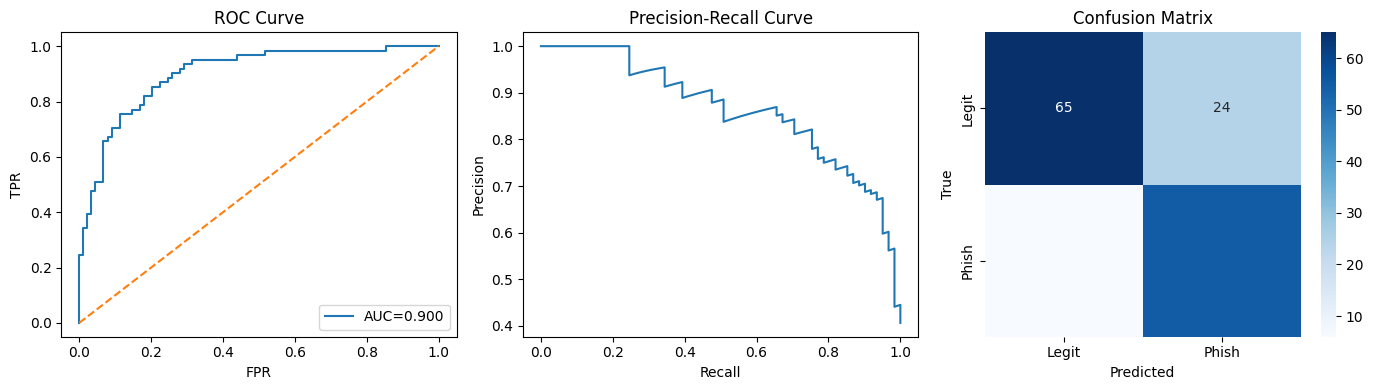

In [24]:
# Evaluate with plots

from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predictions
test_probs = model.predict(test_ds).ravel()
test_true  = np.concatenate([y for (_, y) in test_ds], axis=0)
y_pred     = (test_probs >= 0.15).astype(int)   # use threshold=0.15

# Metrics
print("Test ROC AUC:", roc_auc_score(test_true, test_probs))
print("\nClassification report:\n", classification_report(test_true, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(test_true, y_pred)

# Plot ROC and PR curves
fpr, tpr, _ = roc_curve(test_true, test_probs)
prec, rec, _ = precision_recall_curve(test_true, test_probs)

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(test_true,test_probs):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend()

plt.subplot(1,3,2)
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve")

plt.subplot(1,3,3)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Legit","Phish"], yticklabels=["Legit","Phish"])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

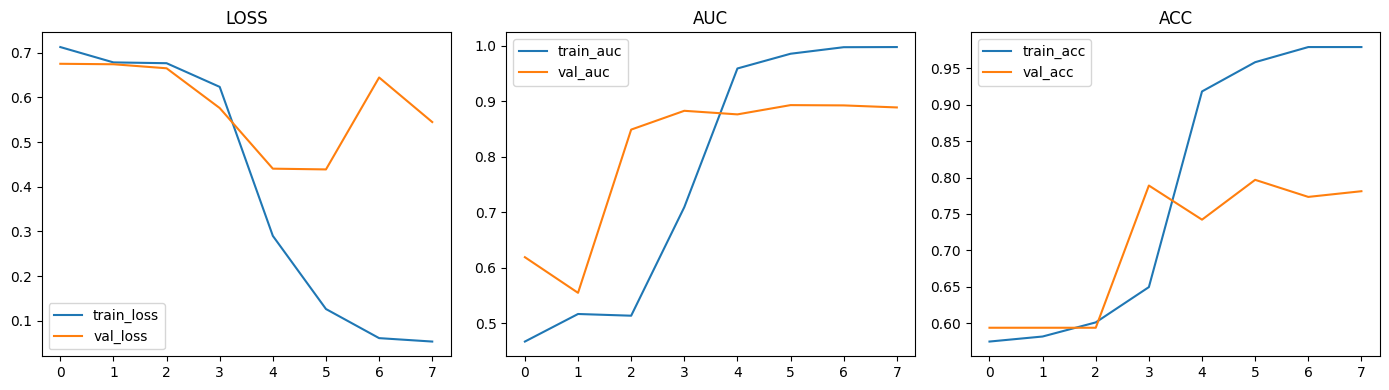

In [25]:
# Training history plot
import matplotlib.pyplot as plt

def plot_history(history, metrics=["loss","auc","acc"]):
    plt.figure(figsize=(14,4))
    for i,m in enumerate(metrics,1):
        plt.subplot(1,len(metrics),i)
        plt.plot(history.history[m], label=f"train_{m}")
        plt.plot(history.history[f"val_{m}"], label=f"val_{m}")
        plt.title(m.upper())
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(hist1, metrics=["loss","auc","acc"])

In [26]:
model.save("hybrid_meta_phishing.keras")

import joblib
joblib.dump(lbl_enc, "template_label_encoder.pkl")

['template_label_encoder.pkl']

In [27]:
def build_image_branch(model_name="EfficientNetB0", input_shape=(224,224,3)):
    img_in = keras.Input(shape=input_shape, name="image")

    # Choose backbone dynamically
    if model_name == "EfficientNetB0":
        base = keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_tensor=img_in)
    elif model_name == "ResNet50":
        base = keras.applications.ResNet50(include_top=False, weights="imagenet", input_tensor=img_in)
    elif model_name == "DenseNet121":
        base = keras.applications.DenseNet121(include_top=False, weights="imagenet", input_tensor=img_in)
    elif model_name == "MobileNetV2":
        base = keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_in)
    elif model_name == "InceptionV3":
        base = keras.applications.InceptionV3(include_top=False, weights="imagenet", input_tensor=img_in)
    else:
        raise ValueError("Unknown model_name")

    base.trainable = False  # start frozen
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.25)(x)

    return img_in, base, x

In [28]:
# Now build the full hybrid with text + metadata + CNN
def build_hybrid(model_name="EfficientNetB0"):
    # Image branch
    img_in, base, x_img = build_image_branch(model_name, input_shape=(*IMG_SIZE,3))

    # Text branch
    txt_in = keras.Input(shape=(), dtype=tf.string, name="subject_text")
    x_txt = vectorizer(txt_in)
    x_txt = layers.Embedding(vocab_size, 128, mask_zero=False)(x_txt)
    x_txt = layers.Bidirectional(layers.LSTM(64))(x_txt)
    x_txt = layers.Dropout(0.25)(x_txt)

    # Metadata branch
    tmp_in  = keras.Input(shape=(), dtype=tf.int32, name="template")
    dark_in = keras.Input(shape=(), dtype=tf.int32, name="dark_mode")

    x_tmp  = layers.CategoryEncoding(num_tokens=n_templates, output_mode="one_hot")(tmp_in)
    x_dark = layers.Reshape((1,))(dark_in)
    x_dark = layers.Lambda(lambda t: tf.cast(t, tf.float32))(x_dark)

    x_meta = layers.Concatenate()([x_tmp, x_dark])
    x_meta = layers.Dense(16, activation="relu")(x_meta)

    # Fusion
    x = layers.Concatenate()([x_img, x_txt, x_meta])
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=[img_in, txt_in, tmp_in, dark_in], outputs=out)
    return model, base

In [29]:
backbones = ["EfficientNetB0", "ResNet50", "DenseNet121", "MobileNetV2"]

results = {}

for b in backbones:
    print(f"\n=== Training {b} ===")
    model, base = build_hybrid(b)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="acc")])
    
    hist = model.fit(train_ds, epochs=5, validation_data=val_ds, verbose=1)
    
    test_probs = model.predict(test_ds).ravel()
    test_true  = np.concatenate([y for (_, y) in test_ds], axis=0)
    test_auc   = roc_auc_score(test_true, test_probs)
    
    results[b] = test_auc
    print(f"{b} Test ROC AUC: {test_auc:.3f}")


=== Training EfficientNetB0 ===
Epoch 1/5
23/23 [==============================] - 44s 944ms/step - loss: 0.6911 - auc: 0.4963 - acc: 0.5803 - val_loss: 0.6743 - val_auc: 0.6078 - val_acc: 0.5938
Epoch 2/5
23/23 [==============================] - 22s 821ms/step - loss: 0.6950 - auc: 0.4955 - acc: 0.5596 - val_loss: 0.6689 - val_auc: 0.7573 - val_acc: 0.5938
Epoch 3/5
23/23 [==============================] - 22s 817ms/step - loss: 0.6484 - auc: 0.6307 - acc: 0.6205 - val_loss: 0.6592 - val_auc: 0.8942 - val_acc: 0.5938
Epoch 4/5
23/23 [==============================] - 23s 845ms/step - loss: 0.3926 - auc: 0.9277 - acc: 0.8255 - val_loss: 0.4687 - val_auc: 0.8885 - val_acc: 0.7969
Epoch 5/5
5/5 [==============================] - 11s 1s/step
EfficientNetB0 Test ROC AUC: 0.893

=== Training ResNet50 ===
94765736/94765736 [==============================] - 31s 0us/step
Epoch 1/5
23/23 [==============================] - 66s 2s/step - loss: 0.7309 - auc: 0.5050 - acc: 0.5443 - val_loss: 0.71

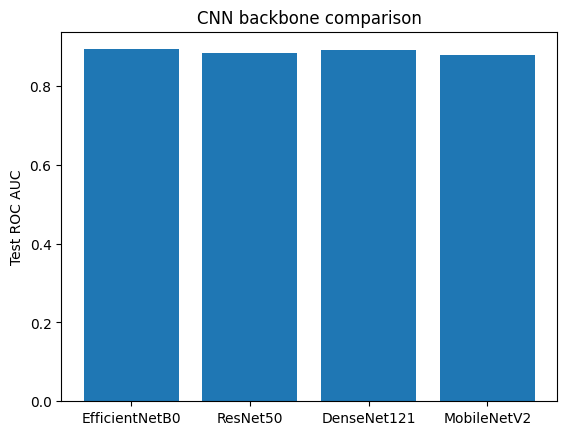

In [30]:
plt.bar(results.keys(), results.values())
plt.ylabel("Test ROC AUC")
plt.title("CNN backbone comparison")
plt.show()


=== Training EfficientNetB0 ===
Epoch 1/20
23/23 [==============================] - 47s 1s/step - loss: 0.7075 - auc: 0.4977 - acc: 0.5526 - val_loss: 0.6884 - val_auc: 0.5248 - val_acc: 0.5938
Epoch 2/20
23/23 [==============================] - 24s 816ms/step - loss: 0.6793 - auc: 0.5190 - acc: 0.5734 - val_loss: 0.6724 - val_auc: 0.6716 - val_acc: 0.5938
Epoch 3/20
23/23 [==============================] - 23s 823ms/step - loss: 0.6559 - auc: 0.6086 - acc: 0.6274 - val_loss: 0.6152 - val_auc: 0.8874 - val_acc: 0.7422
Epoch 4/20
23/23 [==============================] - 23s 806ms/step - loss: 0.4364 - auc: 0.9218 - acc: 0.8352 - val_loss: 0.4767 - val_auc: 0.8639 - val_acc: 0.7656
Epoch 5/20
23/23 [==============================] - 23s 813ms/step - loss: 0.1517 - auc: 0.9813 - acc: 0.9543 - val_loss: 0.5800 - val_auc: 0.8749 - val_acc: 0.7422
Epoch 6/20
23/23 [==============================] - 23s 824ms/step - loss: 0.0803 - auc: 0.9943 - acc: 0.9751 - val_loss: 0.5336 - val_auc: 0.869

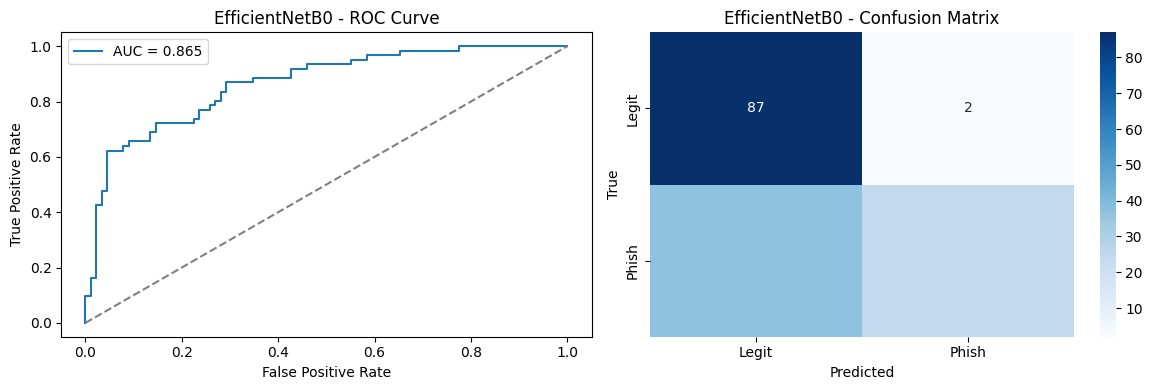


Classification report for EfficientNetB0:
               precision    recall  f1-score   support

         0.0     0.7016    0.9775    0.8169        89
         1.0     0.9231    0.3934    0.5517        61

    accuracy                         0.7400       150
   macro avg     0.8123    0.6855    0.6843       150
weighted avg     0.7917    0.7400    0.7091       150


=== Training ResNet50 ===
Epoch 1/20
23/23 [==============================] - 79s 3s/step - loss: 0.7403 - auc: 0.4883 - acc: 0.5429 - val_loss: 0.6730 - val_auc: 0.5674 - val_acc: 0.5938
Epoch 2/20
23/23 [==============================] - 66s 3s/step - loss: 0.6851 - auc: 0.5305 - acc: 0.5886 - val_loss: 0.7150 - val_auc: 0.6474 - val_acc: 0.5938
Epoch 3/20
23/23 [==============================] - 61s 3s/step - loss: 0.6782 - auc: 0.5482 - acc: 0.5900 - val_loss: 0.6469 - val_auc: 0.8345 - val_acc: 0.6094
Epoch 4/20
23/23 [==============================] - 63s 3s/step - loss: 0.5559 - auc: 0.7824 - acc: 0.6994 - val_los

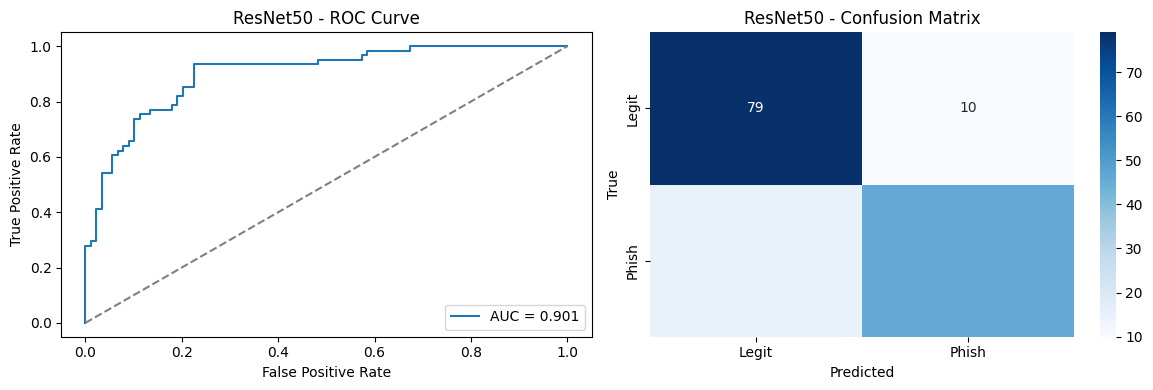


Classification report for ResNet50:
               precision    recall  f1-score   support

         0.0     0.8404    0.8876    0.8634        89
         1.0     0.8214    0.7541    0.7863        61

    accuracy                         0.8333       150
   macro avg     0.8309    0.8209    0.8249       150
weighted avg     0.8327    0.8333    0.8320       150


=== Training DenseNet121 ===
Epoch 1/20
23/23 [==============================] - 89s 2s/step - loss: 0.7093 - auc: 0.5328 - acc: 0.5609 - val_loss: 0.6725 - val_auc: 0.5433 - val_acc: 0.5938
Epoch 2/20
23/23 [==============================] - 53s 2s/step - loss: 0.6812 - auc: 0.5495 - acc: 0.5873 - val_loss: 0.6881 - val_auc: 0.5423 - val_acc: 0.5234
Epoch 3/20
23/23 [==============================] - 272s 12s/step - loss: 0.6420 - auc: 0.6402 - acc: 0.6191 - val_loss: 0.6384 - val_auc: 0.6546 - val_acc: 0.6562
Epoch 4/20
23/23 [==============================] - 51s 2s/step - loss: 0.4281 - auc: 0.8918 - acc: 0.8144 - val_loss

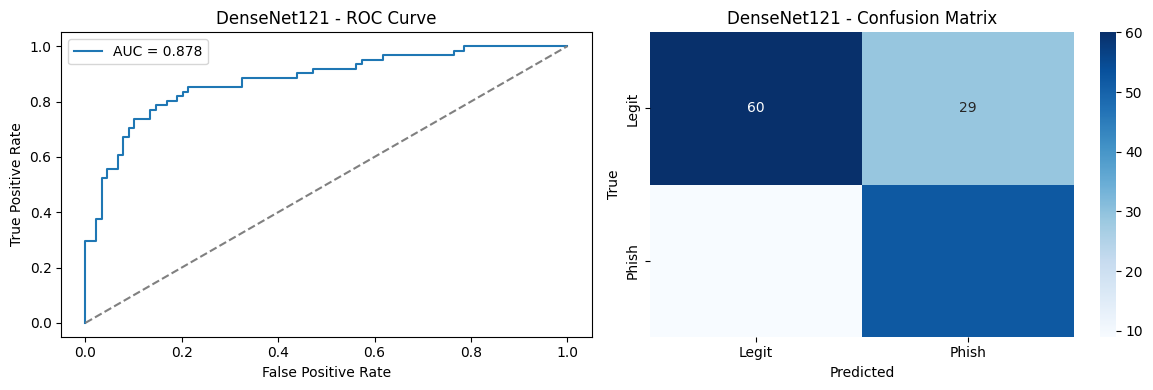


Classification report for DenseNet121:
               precision    recall  f1-score   support

         0.0     0.8696    0.6742    0.7595        89
         1.0     0.6420    0.8525    0.7324        61

    accuracy                         0.7467       150
   macro avg     0.7558    0.7633    0.7459       150
weighted avg     0.7770    0.7467    0.7485       150


=== Training MobileNetV2 ===
Epoch 1/20
23/23 [==============================] - 49s 923ms/step - loss: 0.7083 - auc: 0.5803 - acc: 0.5720 - val_loss: 0.7790 - val_auc: 0.5326 - val_acc: 0.3984
Epoch 2/20
23/23 [==============================] - 18s 533ms/step - loss: 0.6764 - auc: 0.5830 - acc: 0.5956 - val_loss: 0.6944 - val_auc: 0.5335 - val_acc: 0.5078
Epoch 3/20
23/23 [==============================] - 15s 481ms/step - loss: 0.6808 - auc: 0.5881 - acc: 0.5817 - val_loss: 0.6890 - val_auc: 0.6587 - val_acc: 0.5391
Epoch 4/20
23/23 [==============================] - 15s 475ms/step - loss: 0.5516 - auc: 0.7899 - acc: 0.72

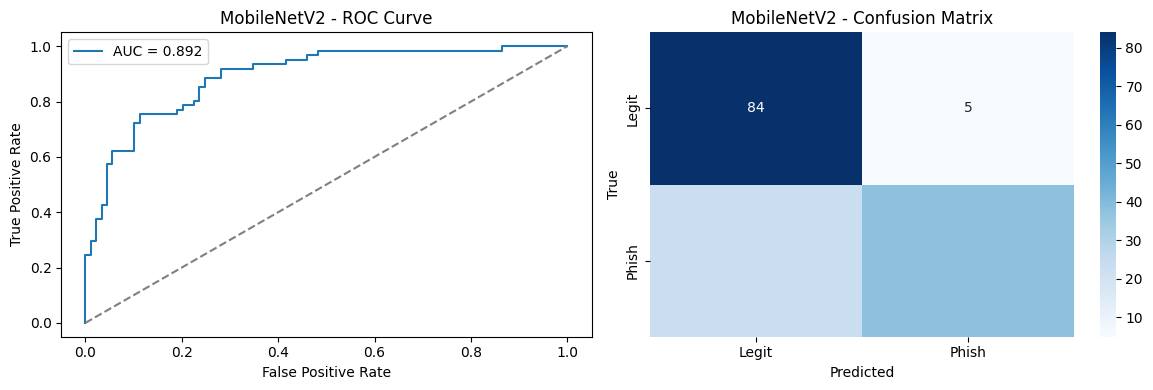


Classification report for MobileNetV2:
               precision    recall  f1-score   support

         0.0     0.7850    0.9438    0.8571        89
         1.0     0.8837    0.6230    0.7308        61

    accuracy                         0.8133       150
   macro avg     0.8344    0.7834    0.7940       150
weighted avg     0.8252    0.8133    0.8058       150


=== Backbone Comparison Summary ===


,Backbone,Test AUC,Accuracy,Precision,Recall,F1-score
0,EfficientNetB0,0.8650,0.7400,0.9231,0.3934,0.5517
1,ResNet50,0.9007,0.8333,0.8214,0.7541,0.7863
2,DenseNet121,0.8777,0.7467,0.6420,0.8525,0.7324
3,MobileNetV2,0.8917,0.8133,0.8837,0.6230,0.7308


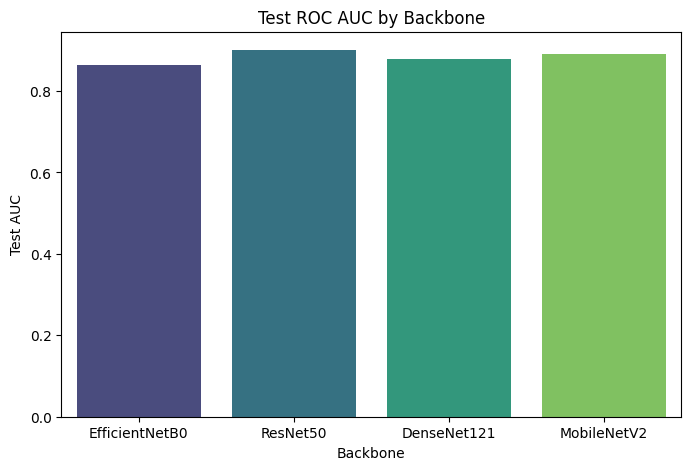

In [31]:
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

backbones = ["EfficientNetB0", "ResNet50", "DenseNet121", "MobileNetV2"]

summary_records = []

for b in backbones:
    print(f"\n=== Training {b} ===")
    
    # Build hybrid model with chosen CNN backbone
    model, base = build_hybrid(b)
    
    # ---------- Stage 1: Frozen CNN ----------
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="acc")]
    )
    
    es = keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True
    )
    
    hist1 = model.fit(
        train_ds,
        epochs=20,  # allow up to 20, but early stopping will stop earlier
        validation_data=val_ds,
        callbacks=[es],
        verbose=1
    )
    
    # ---------- Stage 2: Fine-tune top CNN layers ----------
    # Unfreeze top ~25% of CNN layers for fine-tuning
    for layer in base.layers[int(len(base.layers)*0.75):]:
        if not isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = True
    
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="acc")]
    )
    
    es2 = keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True
    )
    
    hist2 = model.fit(
        train_ds,
        epochs=10,
        validation_data=val_ds,
        callbacks=[es2],
        verbose=1
    )
    
    # ---------- Evaluation ----------
    test_probs = model.predict(test_ds).ravel()
    test_true  = np.concatenate([y for (_, y) in test_ds], axis=0)
    test_auc   = roc_auc_score(test_true, test_probs)
    
    # Use threshold = 0.5 (or set to 0.15 if phishing recall is priority)
    y_pred = (test_probs >= 0.5).astype(int)
    
    # Metrics
    prec  = precision_score(test_true, y_pred)
    rec   = recall_score(test_true, y_pred)
    f1    = f1_score(test_true, y_pred)
    acc   = (y_pred == test_true).mean()
    
    summary_records.append({
        "Backbone": b,
        "Test AUC": round(test_auc,4),
        "Accuracy": round(acc,4),
        "Precision": round(prec,4),
        "Recall": round(rec,4),
        "F1-score": round(f1,4)
    })
    
    # Confusion matrix
    cm = confusion_matrix(test_true, y_pred)
    
    # --- Plot ROC & Confusion Matrix ---
    fpr, tpr, _ = roc_curve(test_true, test_probs)
    
    plt.figure(figsize=(12,4))
    
    # ROC
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{b} - ROC Curve")
    plt.legend()
    
    # Confusion Matrix
    plt.subplot(1,2,2)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Legit","Phish"],
                yticklabels=["Legit","Phish"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{b} - Confusion Matrix")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nClassification report for {b}:\n",
          classification_report(test_true, y_pred, digits=4))

# ---------- Summary ----------
summary_df = pd.DataFrame(summary_records)
print("\n=== Backbone Comparison Summary ===")
display(summary_df)

plt.figure(figsize=(8,5))
sns.barplot(data=summary_df, x="Backbone", y="Test AUC", palette="viridis")
plt.title("Test ROC AUC by Backbone")
plt.show()


===================== EfficientNetB0 =====================
Epoch 1/20
23/23 [==============================] - 55s 1s/step - loss: 0.6856 - auc: 0.5097 - acc: 0.5720 - val_loss: 0.6806 - val_auc: 0.6055 - val_acc: 0.5938
Epoch 2/20
23/23 [==============================] - 24s 845ms/step - loss: 0.6743 - auc: 0.5473 - acc: 0.5831 - val_loss: 0.6665 - val_auc: 0.7520 - val_acc: 0.5938
Epoch 3/20
23/23 [==============================] - 24s 848ms/step - loss: 0.5939 - auc: 0.7473 - acc: 0.6981 - val_loss: 0.5226 - val_auc: 0.8928 - val_acc: 0.7266
Epoch 4/20
23/23 [==============================] - 25s 918ms/step - loss: 0.2984 - auc: 0.9511 - acc: 0.8726 - val_loss: 0.4419 - val_auc: 0.8884 - val_acc: 0.7734
Epoch 5/20
23/23 [==============================] - 24s 869ms/step - loss: 0.1033 - auc: 0.9909 - acc: 0.9723 - val_loss: 0.4680 - val_auc: 0.8889 - val_acc: 0.7891
Epoch 6/20
23/23 [==============================] - 23s 814ms/step - loss: 0.0776 - auc: 0.9960 - acc: 0.9709 - val_lo

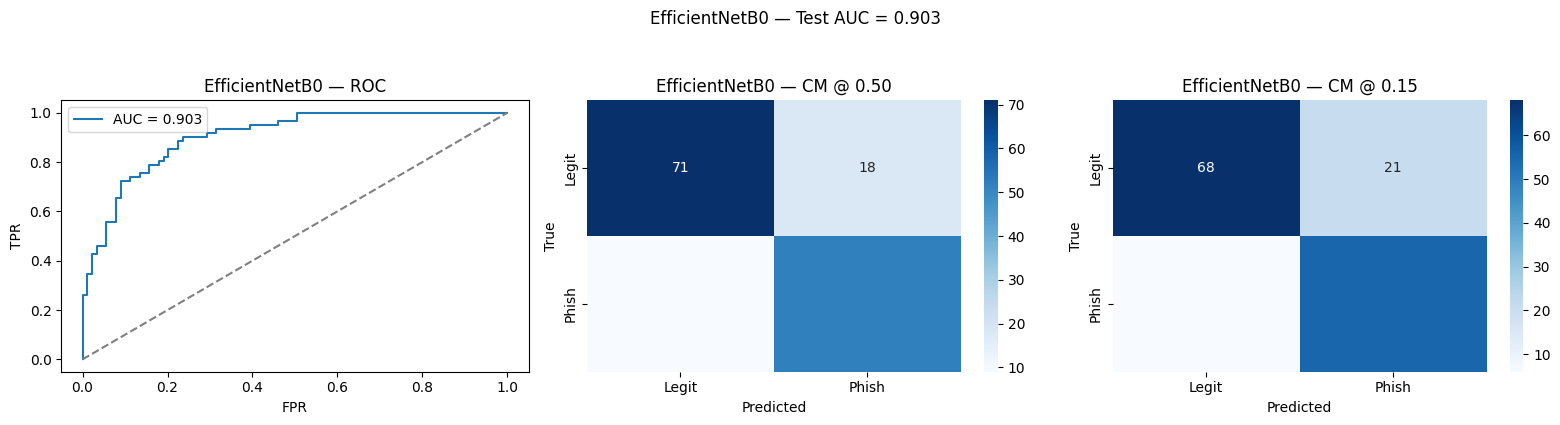

Classification report for EfficientNetB0 @ 0.50
               precision    recall  f1-score   support

         0.0     0.8875    0.7978    0.8402        89
         1.0     0.7429    0.8525    0.7939        61

    accuracy                         0.8200       150
   macro avg     0.8152    0.8251    0.8171       150
weighted avg     0.8287    0.8200    0.8214       150

Classification report for EfficientNetB0 @ 0.15
               precision    recall  f1-score   support

         0.0     0.9189    0.7640    0.8344        89
         1.0     0.7237    0.9016    0.8029        61

    accuracy                         0.8200       150
   macro avg     0.8213    0.8328    0.8186       150
weighted avg     0.8395    0.8200    0.8216       150


===================== ResNet50 =====================
Epoch 1/20
23/23 [==============================] - 115s 4s/step - loss: 0.7347 - auc: 0.5114 - acc: 0.5402 - val_loss: 0.6806 - val_auc: 0.5397 - val_acc: 0.5938
Epoch 2/20
23/23 [=============

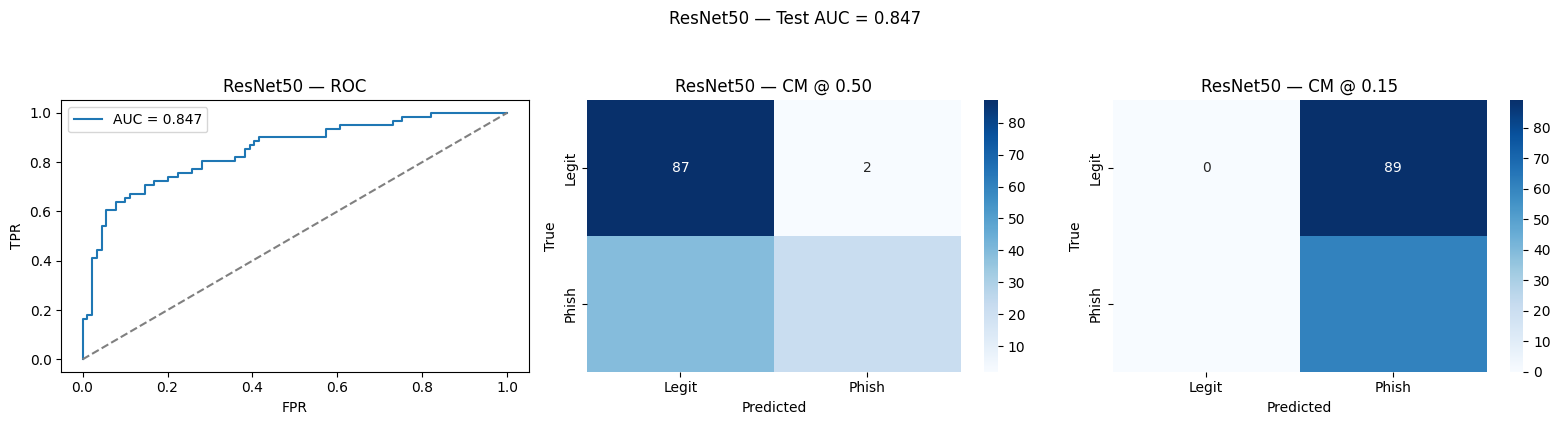

Classification report for ResNet50 @ 0.50
               precision    recall  f1-score   support

         0.0     0.6905    0.9775    0.8093        89
         1.0     0.9167    0.3607    0.5176        61

    accuracy                         0.7267       150
   macro avg     0.8036    0.6691    0.6635       150
weighted avg     0.7825    0.7267    0.6907       150

Classification report for ResNet50 @ 0.15
               precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000        89
         1.0     0.4067    1.0000    0.5782        61

    accuracy                         0.4067       150
   macro avg     0.2033    0.5000    0.2891       150
weighted avg     0.1654    0.4067    0.2351       150


===================== DenseNet121 =====================


d:\multimodal email phishing\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\multimodal email phishing\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\multimodal email phishing\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

Epoch 1/20
23/23 [==============================] - 74s 3s/step - loss: 0.7075 - auc: 0.5659 - acc: 0.5748 - val_loss: 0.7433 - val_auc: 0.5577 - val_acc: 0.5000
Epoch 2/20
23/23 [==============================] - 63s 3s/step - loss: 0.6941 - auc: 0.5578 - acc: 0.5762 - val_loss: 0.6758 - val_auc: 0.5648 - val_acc: 0.5781
Epoch 3/20
23/23 [==============================] - 57s 2s/step - loss: 0.6651 - auc: 0.6108 - acc: 0.6094 - val_loss: 0.6547 - val_auc: 0.6853 - val_acc: 0.6328
Epoch 4/20
23/23 [==============================] - 56s 2s/step - loss: 0.5383 - auc: 0.8044 - acc: 0.7202 - val_loss: 0.5200 - val_auc: 0.8811 - val_acc: 0.7344
Epoch 5/20
23/23 [==============================] - 59s 2s/step - loss: 0.2450 - auc: 0.9602 - acc: 0.9155 - val_loss: 0.4039 - val_auc: 0.9046 - val_acc: 0.8047
Epoch 6/20
23/23 [==============================] - 60s 2s/step - loss: 0.0805 - auc: 0.9957 - acc: 0.9723 - val_loss: 0.4968 - val_auc: 0.9093 - val_acc: 0.7969
Epoch 7/20
23/23 [==========

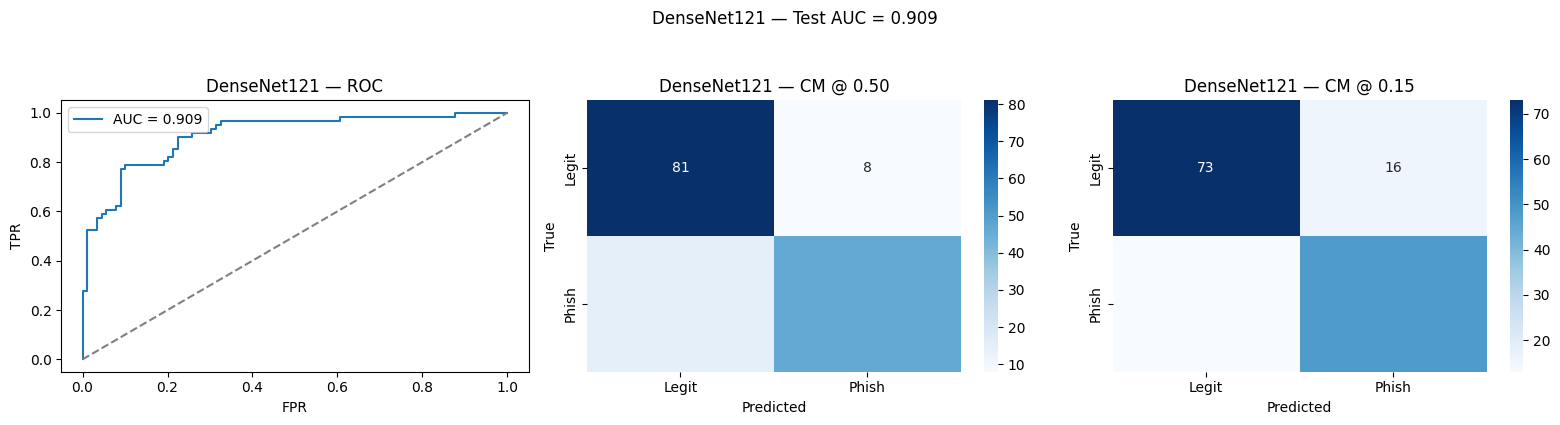

Classification report for DenseNet121 @ 0.50
               precision    recall  f1-score   support

         0.0     0.8438    0.9101    0.8757        89
         1.0     0.8519    0.7541    0.8000        61

    accuracy                         0.8467       150
   macro avg     0.8478    0.8321    0.8378       150
weighted avg     0.8470    0.8467    0.8449       150

Classification report for DenseNet121 @ 0.15
               precision    recall  f1-score   support

         0.0     0.8488    0.8202    0.8343        89
         1.0     0.7500    0.7869    0.7680        61

    accuracy                         0.8067       150
   macro avg     0.7994    0.8036    0.8011       150
weighted avg     0.8086    0.8067    0.8073       150


===================== MobileNetV2 =====================
Epoch 1/20
23/23 [==============================] - 30s 547ms/step - loss: 0.7040 - auc: 0.5466 - acc: 0.5540 - val_loss: 0.7658 - val_auc: 0.5099 - val_acc: 0.4375
Epoch 2/20
23/23 [==============

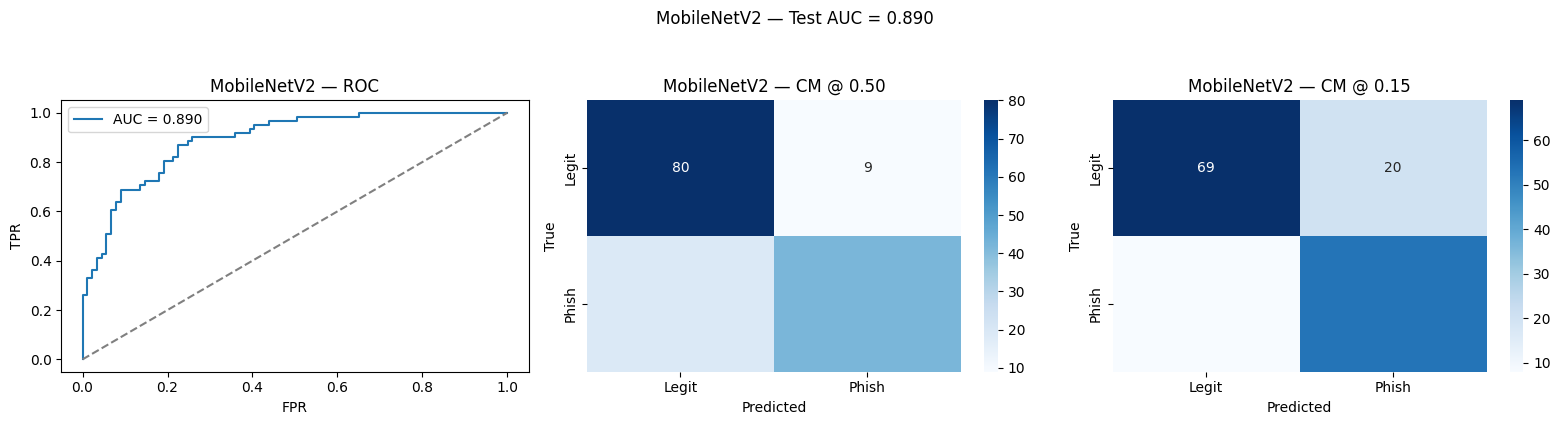

Classification report for MobileNetV2 @ 0.50
               precision    recall  f1-score   support

         0.0     0.8081    0.8989    0.8511        89
         1.0     0.8235    0.6885    0.7500        61

    accuracy                         0.8133       150
   macro avg     0.8158    0.7937    0.8005       150
weighted avg     0.8144    0.8133    0.8100       150

Classification report for MobileNetV2 @ 0.15
               precision    recall  f1-score   support

         0.0     0.8961    0.7753    0.8313        89
         1.0     0.7260    0.8689    0.7910        61

    accuracy                         0.8133       150
   macro avg     0.8111    0.8221    0.8112       150
weighted avg     0.8269    0.8133    0.8149       150


=== Backbone Comparison (AUC + metrics at 0.50 and 0.15) ===


,Backbone,AUC,Acc@0.50,Prec@0.50,Rec@0.50,F1@0.50,Acc@0.15,Prec@0.15,Rec@0.15,F1@0.15
2,DenseNet121,0.9092,0.8467,0.8519,0.7541,0.8000,0.8067,0.7500,0.7869,0.7680
0,EfficientNetB0,0.9033,0.8200,0.7429,0.8525,0.7939,0.8200,0.7237,0.9016,0.8029
3,MobileNetV2,0.8900,0.8133,0.8235,0.6885,0.7500,0.8133,0.7260,0.8689,0.7910
1,ResNet50,0.8466,0.7267,0.9167,0.3607,0.5176,0.4067,0.4067,1.0000,0.5782


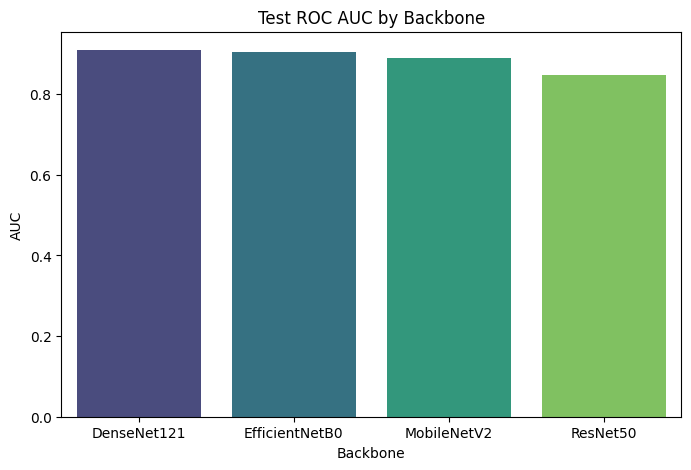

In [32]:
# Cell — Backbone comparison with dual-threshold evaluation and detailed plots

from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tensorflow import keras

# Backbones to compare (you can add 'InceptionV3', 'EfficientNetB1', etc., if you like)
backbones = ["EfficientNetB0", "ResNet50", "DenseNet121", "MobileNetV2"]

# Two thresholds: standard (0.50) and recall-leaning (0.15)
THRESHOLDS = [0.50, 0.15]

summary_rows = []

def metrics_at_threshold(y_true, y_prob, thr):
    """Compute Accuracy, Precision, Recall, F1 at a specific threshold."""
    y_pred = (y_prob >= thr).astype(int)
    acc = (y_pred == y_true).mean()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    return acc, prec, rec, f1, y_pred

for b in backbones:
    print(f"\n===================== {b} =====================")

    # ---------- Build hybrid model for this backbone ----------
    model, base = build_hybrid(b)

    # ---------- Stage 1: train with CNN frozen ----------
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="acc")]
    )
    es1 = keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=3, restore_best_weights=True
    )
    hist1 = model.fit(
        train_ds, epochs=20, validation_data=val_ds, callbacks=[es1], verbose=1
    )

    # ---------- Stage 2: fine-tune upper CNN layers ----------
    # Unfreeze top ~25% of the backbone, keep BatchNorm frozen (stabler FT)
    cutoff = int(len(base.layers) * 0.75)
    for i, layer in enumerate(base.layers):
        if i >= cutoff and not isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = True

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="acc")]
    )
    es2 = keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=3, restore_best_weights=True
    )
    hist2 = model.fit(
        train_ds, epochs=10, validation_data=val_ds, callbacks=[es2], verbose=1
    )

    # ---------- Test-time evaluation ----------
    test_probs = model.predict(test_ds).ravel()
    test_true  = np.concatenate([y for (_, y) in test_ds], axis=0)
    test_auc   = roc_auc_score(test_true, test_probs)
    fpr, tpr, _ = roc_curve(test_true, test_probs)

    # Compute metrics at both thresholds
    per_thr_metrics = {}
    per_thr_preds   = {}
    for thr in THRESHOLDS:
        acc, prec, rec, f1, y_pred = metrics_at_threshold(test_true, test_probs, thr)
        per_thr_metrics[thr] = (acc, prec, rec, f1)
        per_thr_preds[thr]   = y_pred

    # ---------- Plots: ROC + two confusion matrices ----------
    fig = plt.figure(figsize=(16,4))
    # ROC (threshold-independent)
    ax1 = plt.subplot(1,3,1)
    ax1.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
    ax1.plot([0,1],[0,1],'--', color='gray')
    ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR"); ax1.set_title(f"{b} — ROC")
    ax1.legend()

    # Confusion matrix @ 0.50
    ax2 = plt.subplot(1,3,2)
    cm_50 = confusion_matrix(test_true, per_thr_preds[0.50])
    sns.heatmap(cm_50, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Legit","Phish"], yticklabels=["Legit","Phish"], ax=ax2)
    ax2.set_title(f"{b} — CM @ 0.50")
    ax2.set_xlabel("Predicted"); ax2.set_ylabel("True")

    # Confusion matrix @ 0.15
    ax3 = plt.subplot(1,3,3)
    cm_15 = confusion_matrix(test_true, per_thr_preds[0.15])
    sns.heatmap(cm_15, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Legit","Phish"], yticklabels=["Legit","Phish"], ax=ax3)
    ax3.set_title(f"{b} — CM @ 0.15")
    ax3.set_xlabel("Predicted"); ax3.set_ylabel("True")

    plt.suptitle(f"{b} — Test AUC = {test_auc:.3f}", y=1.05, fontsize=12)
    plt.tight_layout()
    plt.show()

    # ---------- Classification reports (printed) ----------
    print(f"Classification report for {b} @ 0.50\n",
          classification_report(test_true, per_thr_preds[0.50], digits=4))
    print(f"Classification report for {b} @ 0.15\n",
          classification_report(test_true, per_thr_preds[0.15], digits=4))

    # ---------- Collect summary row ----------
    acc50, prec50, rec50, f150 = per_thr_metrics[0.50]
    acc15, prec15, rec15, f115 = per_thr_metrics[0.15]

    summary_rows.append({
        "Backbone": b,
        "AUC": round(test_auc,4),

        "Acc@0.50": round(acc50,4),
        "Prec@0.50": round(prec50,4),
        "Rec@0.50": round(rec50,4),
        "F1@0.50": round(f150,4),

        "Acc@0.15": round(acc15,4),
        "Prec@0.15": round(prec15,4),
        "Rec@0.15": round(rec15,4),
        "F1@0.15": round(f115,4),
    })

# ---------- Final summary table + AUC bar ----------
summary_df = pd.DataFrame(summary_rows).sort_values("AUC", ascending=False)
print("\n=== Backbone Comparison (AUC + metrics at 0.50 and 0.15) ===")
display(summary_df)

plt.figure(figsize=(8,5))
sns.barplot(data=summary_df, x="Backbone", y="AUC", palette="viridis")
plt.title("Test ROC AUC by Backbone")
plt.show()

In [35]:
def predict_single_email(model, image_path, subject, template, dark_mode, threshold=0.15):
    TEMPLATE_MAP = {
        "account_verification": 0,
        "invoice": 1,
        "bank_alert": 2,
        "delivery": 3
    }

    img = load_image(image_path)
    img = tf.expand_dims(img, axis=0)

    subject = tf.constant([subject])
    template = tf.constant([TEMPLATE_MAP[template]])
    dark_mode = tf.constant([dark_mode])

    prob = model.predict([img, subject, template, dark_mode])[0][0]

    if prob >= threshold:
        return f"PHISHING EMAIL ⚠️ (Confidence: {prob:.2f})"
    else:
        return f"LEGITIMATE EMAIL ✅ (Confidence: {1-prob:.2f})"


In [36]:
result = predict_single_email(
    model=model,
    image_path="sample.png",
    subject="Verify your bank account",
    template="account_verification",
    dark_mode=False
)

print(result)


1/1 [==============================] - 3s 3s/step
PHISHING EMAIL ⚠️ (Confidence: 1.00)


In [13]:
import pandas as pd
import numpy as np

CSV_PATH = r"D:\multimodal email phishing\data\email_images\manifest_with_url.csv"
df = pd.read_csv(CSV_PATH)

print("Dataset loaded with URL features ✅")
print(df.columns)

Dataset loaded with URL features ✅
Index(['image_path', 'label', 'row_index', 'template', 'dark_mode', 'subject',
       'url', 'url_length', 'domain_length', 'num_dots', 'num_hyphens',
       'num_digits', 'has_ip', 'is_https', 'has_keyword'],
      dtype='object')


In [14]:
URL_FEATURE_COLUMNS = [
    "url_length",
    "domain_length",
    "num_dots",
    "num_hyphens",
    "num_digits",
    "has_ip",
    "is_https",
    "has_keyword"
]

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def make_dataset_full(frame, training=False):

    paths   = frame['image_path'].astype(str).tolist()
    texts   = frame['subject'].astype(str).tolist()
    labels  = frame['label'].astype(np.float32).tolist()
    tmps    = frame['template_enc'].astype(np.int32).tolist()
    darks   = frame['dark_mode_int'].astype(np.int32).tolist()

    url_features = frame[URL_FEATURE_COLUMNS].astype(np.float32).values

    ds_img   = tf.data.Dataset.from_tensor_slices(paths).map(lambda p: load_image(p))
    ds_txt   = tf.data.Dataset.from_tensor_slices(texts)
    ds_lab   = tf.data.Dataset.from_tensor_slices(labels)
    ds_tmp   = tf.data.Dataset.from_tensor_slices(tmps)
    ds_dark  = tf.data.Dataset.from_tensor_slices(darks)
    ds_url   = tf.data.Dataset.from_tensor_slices(url_features)

    ds = tf.data.Dataset.zip((
        {
            "image": ds_img,
            "subject_text": ds_txt,
            "template": ds_tmp,
            "dark_mode": ds_dark,
            "url_features": ds_url
        },
        ds_lab
    ))

    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split

CSV_PATH = r"D:\multimodal email phishing\data\email_images\manifest_with_url.csv"
df = pd.read_csv(CSV_PATH)

# Train / Val / Test split
train_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df['label'], random_state=42
)

train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df['label'], random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 722
Val: 128
Test: 150


In [17]:
from sklearn.preprocessing import LabelEncoder

lbl_enc = LabelEncoder()

train_df["template_enc"] = lbl_enc.fit_transform(train_df["template"])
val_df["template_enc"]   = lbl_enc.transform(val_df["template"])
test_df["template_enc"]  = lbl_enc.transform(test_df["template"])

for df_ in [train_df, val_df, test_df]:
    df_["dark_mode_int"] = df_["dark_mode"].astype(int)

n_templates = len(lbl_enc.classes_)

print("Metadata encoding done ✅")

Metadata encoding done ✅


In [18]:
from tensorflow.keras import layers

MAX_TOKENS = 2000
MAX_LEN = 24

vectorizer = layers.TextVectorization(
    standardize='lower_and_strip_punctuation',
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=MAX_LEN,
)

vectorizer.adapt(train_df['subject'].astype(str).values)

vocab_size = len(vectorizer.get_vocabulary())

print("Vectorizer ready ✅")
print("Vocabulary size:", vocab_size)



Vectorizer ready ✅
Vocabulary size: 1630


In [19]:
keras.backend.clear_session()

# IMAGE BRANCH
img_in = keras.Input(shape=(224,224,3), name="image")
base = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_tensor=img_in
)
base.trainable = False
x_img = layers.GlobalAveragePooling2D()(base.output)

# TEXT BRANCH
txt_in = keras.Input(shape=(), dtype=tf.string, name="subject_text")
x_txt = vectorizer(txt_in)
x_txt = layers.Embedding(vocab_size, 128, mask_zero=False)(x_txt)
x_txt = layers.Bidirectional(layers.LSTM(64))(x_txt)

# METADATA BRANCH
tmp_in  = keras.Input(shape=(), dtype=tf.int32, name="template")
dark_in = keras.Input(shape=(), dtype=tf.int32, name="dark_mode")

x_tmp  = layers.CategoryEncoding(num_tokens=n_templates, output_mode="one_hot")(tmp_in)
x_dark = layers.Reshape((1,))(dark_in)
x_dark = layers.Lambda(lambda t: tf.cast(t, tf.float32))(x_dark)

x_meta = layers.Concatenate()([x_tmp, x_dark])
x_meta = layers.Dense(16, activation="relu")(x_meta)

# 🆕 URL BRANCH
url_in = keras.Input(shape=(len(URL_FEATURE_COLUMNS),), name="url_features")
x_url  = layers.Dense(32, activation="relu")(url_in)
x_url  = layers.Dense(16, activation="relu")(x_url)

# 🔗 FUSION
x = layers.Concatenate()([x_img, x_txt, x_meta, x_url])
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
out = layers.Dense(1, activation="sigmoid", name="phish_prob")(x)

model = keras.Model(
    inputs=[img_in, txt_in, tmp_in, dark_in, url_in],
    outputs=out
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image (InputLayer)          [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['image[0][0]']               
                                                                                                  
 normalization (Normalizati  (None, 224, 224, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 224, 224, 3)          0         ['normalization[0][0]']  

In [20]:
import tensorflow as tf

IMG_SIZE = (224, 224)

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img

In [21]:
from pathlib import Path

# Correct image folder path
IMG_DIR = Path(r"D:\multimodal email phishing\data\email_images\email_images")

# Recreate correct image_path
df["image_path"] = df["row_index"].apply(
    lambda i: str(IMG_DIR / f"email_{int(i):05d}.png")
)

# Verify
print(df["image_path"].head())

0    D:\multimodal email phishing\data\email_images...
1    D:\multimodal email phishing\data\email_images...
2    D:\multimodal email phishing\data\email_images...
3    D:\multimodal email phishing\data\email_images...
4    D:\multimodal email phishing\data\email_images...
Name: image_path, dtype: object


In [22]:
import os

print(os.path.exists(df["image_path"].iloc[0]))

True


In [23]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df['label'], random_state=42
)

train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df['label'], random_state=42
)

print("Train:", len(train_df))

Train: 722


In [24]:
from sklearn.preprocessing import LabelEncoder

lbl_enc = LabelEncoder()

train_df["template_enc"] = lbl_enc.fit_transform(train_df["template"])
val_df["template_enc"]   = lbl_enc.transform(val_df["template"])
test_df["template_enc"]  = lbl_enc.transform(test_df["template"])

for df_ in [train_df, val_df, test_df]:
    df_["dark_mode_int"] = df_["dark_mode"].astype(int)

print("Metadata encoding done ✅")

Metadata encoding done ✅


In [25]:
train_ds = make_dataset_full(train_df, training=True)
val_ds   = make_dataset_full(val_df)
test_ds  = make_dataset_full(test_df)

In [27]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc")
    ]
)

In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

Epoch 1/8
23/23 [==============================] - 38s 1s/step - loss: 0.5120 - auc: 0.8509 - acc: 0.7590 - val_loss: 0.2515 - val_auc: 1.0000 - val_acc: 1.0000
Epoch 2/8
23/23 [==============================] - 21s 922ms/step - loss: 0.1703 - auc: 0.9962 - acc: 0.9681 - val_loss: 0.0325 - val_auc: 1.0000 - val_acc: 1.0000
Epoch 3/8
23/23 [==============================] - 23s 1s/step - loss: 0.0219 - auc: 1.0000 - acc: 0.9986 - val_loss: 0.0074 - val_auc: 1.0000 - val_acc: 1.0000
Epoch 4/8
23/23 [==============================] - 22s 969ms/step - loss: 0.0078 - auc: 1.0000 - acc: 0.9986 - val_loss: 0.0021 - val_auc: 1.0000 - val_acc: 1.0000
Epoch 5/8
23/23 [==============================] - 21s 929ms/step - loss: 0.0016 - auc: 1.0000 - acc: 1.0000 - val_loss: 0.0011 - val_auc: 1.0000 - val_acc: 1.0000
Epoch 6/8
23/23 [==============================] - 22s 962ms/step - loss: 9.9868e-04 - auc: 1.0000 - acc: 1.0000 - val_loss: 8.4023e-04 - val_auc: 1.0000 - val_acc: 1.0000
Epoch 7/8
23/2

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

test_probs = model.predict(test_ds).ravel()
test_true  = np.concatenate([y for (_, y) in test_ds], axis=0)

print("Test ROC AUC:", roc_auc_score(test_true, test_probs))

y_pred = (test_probs >= 0.5).astype(int)

print("\nClassification Report:\n")
print(classification_report(test_true, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(test_true, y_pred))

5/5 [==============================] - 9s 1s/step
Test ROC AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        89
         1.0       1.00      1.00      1.00        61

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150


Confusion Matrix:

[[89  0]
 [ 0 61]]


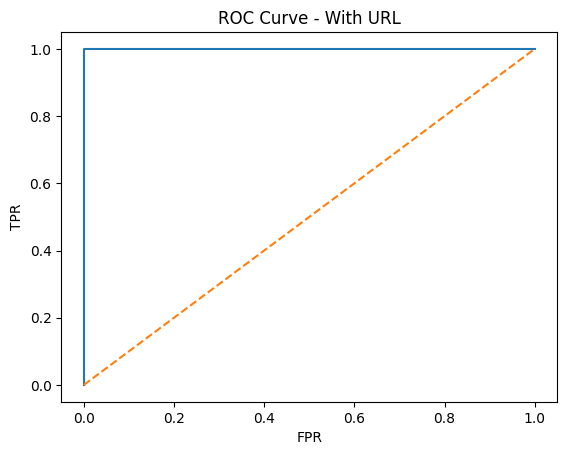

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(test_true, test_probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - With URL")
plt.show()

In [31]:
old_model = keras.models.load_model(
    "hybrid_meta_phishing.keras",
    safe_mode=False
)

In [32]:
def make_dataset_without_url(frame, training=False):
    paths   = frame['image_path'].astype(str).tolist()
    texts   = frame['subject'].astype(str).tolist()
    labels  = frame['label'].astype(np.float32).tolist()
    tmps    = frame['template_enc'].astype(np.int32).tolist()
    darks   = frame['dark_mode_int'].astype(np.int32).tolist()

    ds_img   = tf.data.Dataset.from_tensor_slices(paths).map(lambda p: load_image(p))
    ds_txt   = tf.data.Dataset.from_tensor_slices(texts)
    ds_lab   = tf.data.Dataset.from_tensor_slices(labels)
    ds_tmp   = tf.data.Dataset.from_tensor_slices(tmps)
    ds_dark  = tf.data.Dataset.from_tensor_slices(darks)

    ds = tf.data.Dataset.zip((
        {
            "image": ds_img,
            "subject_text": ds_txt,
            "template": ds_tmp,
            "dark_mode": ds_dark
        },
        ds_lab
    ))

    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

In [33]:
test_ds_without_url = make_dataset_without_url(test_df)

In [34]:
old_probs = old_model.predict(test_ds_without_url).ravel()
old_pred  = (old_probs >= 0.5).astype(int)

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

old_results = {
    "AUC": roc_auc_score(test_true, old_probs),
    "Accuracy": accuracy_score(test_true, old_pred),
    "Precision": precision_score(test_true, old_pred),
    "Recall": recall_score(test_true, old_pred),
    "F1": f1_score(test_true, old_pred)
}

print("Without URL:", old_results)

5/5 [==============================] - 8s 1s/step
Without URL: {'AUC': 0.8999815804015473, 'Accuracy': 0.8133333333333334, 'Precision': 0.7323943661971831, 'Recall': 0.8524590163934426, 'F1': 0.7878787878787878}


In [35]:
new_probs = model.predict(test_ds).ravel()
new_pred  = (new_probs >= 0.5).astype(int)

new_results = {
    "AUC": roc_auc_score(test_true, new_probs),
    "Accuracy": accuracy_score(test_true, new_pred),
    "Precision": precision_score(test_true, new_pred),
    "Recall": recall_score(test_true, new_pred),
    "F1": f1_score(test_true, new_pred)
}

print("With URL:", new_results)

5/5 [==============================] - 5s 987ms/step
With URL: {'AUC': 1.0, 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}


In [36]:
import pandas as pd

comparison = pd.DataFrame([old_results, new_results],
                          index=["Without URL", "With URL"])

print(comparison)

                  AUC  Accuracy  Precision    Recall        F1
Without URL  0.899982  0.813333   0.732394  0.852459  0.787879
With URL     1.000000  1.000000   1.000000  1.000000  1.000000


In [37]:
import numpy as np
import tensorflow as tf

def predict_email(image_path, subject, template, dark_mode, url_features, threshold=0.5):
    
    # --- Prepare Image ---
    img = load_image(image_path)
    img = tf.expand_dims(img, axis=0)

    # --- Prepare Text ---
    subject = tf.constant([subject])

    # --- Prepare Metadata ---
    template_encoded = lbl_enc.transform([template])
    template_encoded = tf.constant(template_encoded)

    dark_mode_int = tf.constant([int(dark_mode)])

    # --- Prepare URL Features ---
    url_features = tf.constant([url_features], dtype=tf.float32)

    # --- Predict ---
    prob = model.predict({
        "image": img,
        "subject_text": subject,
        "template": template_encoded,
        "dark_mode": dark_mode_int,
        "url_features": url_features
    })[0][0]

    if prob >= threshold:
        return f"⚠️ PHISHING EMAIL (Confidence: {prob:.4f})"
    else:
        return f"✅ LEGITIMATE EMAIL (Confidence: {prob:.4f})"

In [38]:
URL_FEATURE_COLUMNS = [
    "has_ip",
    "has_https",
    "num_dots",
    "num_subdomains",
    "url_length",
    "has_special_char",
    "has_shortener",
    "has_suspicious_word"
]

In [39]:
print(URL_FEATURE_COLUMNS)
print(len(URL_FEATURE_COLUMNS))

['has_ip', 'has_https', 'num_dots', 'num_subdomains', 'url_length', 'has_special_char', 'has_shortener', 'has_suspicious_word']
8


In [9]:
url_features = [0,0,1,1,38,1,0,1]

In [41]:
result = predict_email(
    image_path="sample.png",
    subject="Verify your PayPal account",
    template="Outlook",
    dark_mode=False,
    url_features=url_features
)

print(result)

1/1 [==============================] - 5s 5s/step
⚠️ PHISHING EMAIL (Confidence: 1.0000)
